### Initial Data Exploration

In [35]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer

In [36]:
# Load Dataset
df = pd.read_csv(r"D:\customer-churn-project(new)\data\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
# display the basic information
df.shape

(7043, 21)

In [38]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [39]:
cat_column = df.select_dtypes(include='object')
cat_column.head()

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,151.65,Yes


In [40]:
num_col = df.select_dtypes(include=['int64','float64'])
num_col.head()

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [42]:
# check the null values in dataset
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [46]:
# Data Cleaning and Preprocessing
df_clean = df.copy()

In [47]:
df_clean['TotalCharges'].isnull().sum()

np.int64(11)

In [48]:
df_clean = df_clean[df_clean['TotalCharges'].notna()]

In [49]:
df_clean['TotalCharges'].isnull().sum()

np.int64(0)

In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [51]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype('object')

In [52]:
df_clean['SeniorCitizen'].info()

<class 'pandas.core.series.Series'>
Index: 7032 entries, 0 to 7042
Series name: SeniorCitizen
Non-Null Count  Dtype 
--------------  ----- 
7032 non-null   object
dtypes: object(1)
memory usage: 109.9+ KB


In [53]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Exploratory Data Analysis

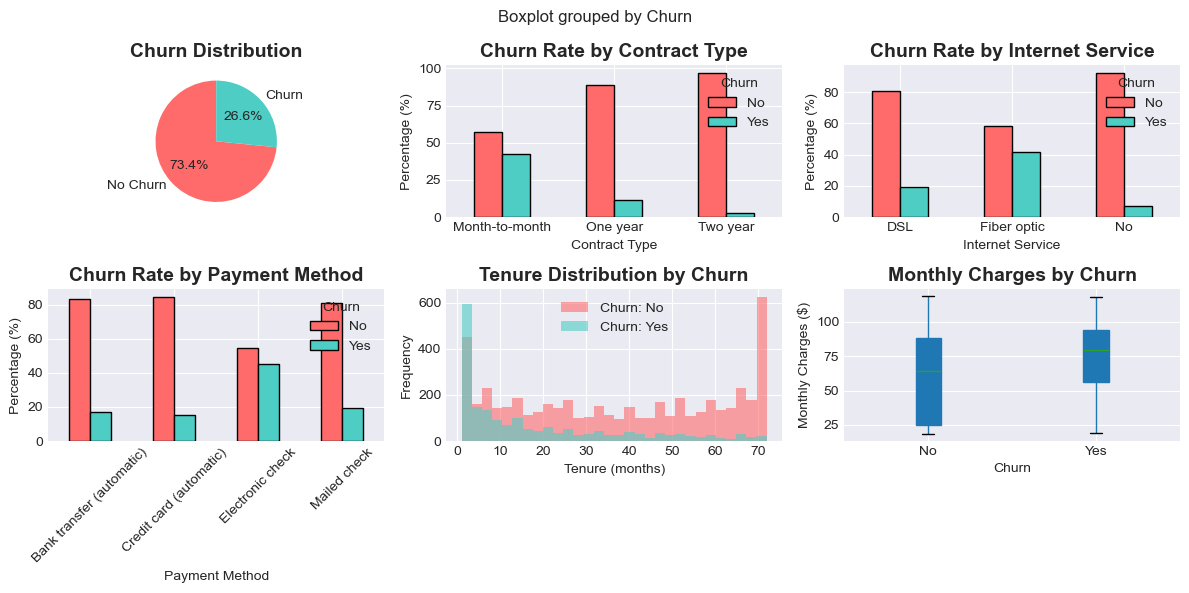

In [54]:
# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig,axes = plt.subplots(2,3,figsize=(15,10))

# 1. Churn Distribution
ax1 = axes[0,0]
churn_counts = df_clean['Churn'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
ax1.pie(churn_counts.values,labels =['No Churn', 'Churn'],autopct = '%1.1f%%',
        colors = colors,startangle=90 )
ax1.set_title('Churn Distribution', fontsize=14, fontweight='bold')


# 2. Churn by Contract Type
ax2 = axes[0, 1]
contract_churn = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
ax2.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Contract Type')
ax2.set_ylabel('Percentage (%)')
ax2.legend(title='Churn')
ax2.tick_params(axis='x', rotation=0)

# 3. Churn by Internet Service
ax3 = axes[0, 2]
internet_churn = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=ax3, color=colors, edgecolor='black')
ax3.set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
ax3.set_xlabel('Internet Service')
ax3.set_ylabel('Percentage (%)')
ax3.legend(title='Churn')
ax3.tick_params(axis='x', rotation=0)

# 4. Churn by Payment Method
ax4 = axes[1, 0]
payment_churn = pd.crosstab(df_clean['PaymentMethod'], df_clean['Churn'], normalize='index') * 100
payment_churn.plot(kind='bar', ax=ax4, color=colors, edgecolor='black', figsize=(12, 6))
ax4.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax4.set_xlabel('Payment Method')
ax4.set_ylabel('Percentage (%)')
ax4.legend(title='Churn')
ax4.tick_params(axis='x', rotation=45)


# 5. Tenure Distribution by Churn
ax5 = axes[1, 1]
for churn_status, color in zip(['No', 'Yes'], colors):
    subset = df_clean[df_clean['Churn'] == churn_status]['tenure']
    ax5.hist(subset, bins=30, alpha=0.6, label=f'Churn: {churn_status}', color=color)
ax5.set_title('Tenure Distribution by Churn', fontsize=14, fontweight='bold')
ax5.set_xlabel('Tenure (months)')
ax5.set_ylabel('Frequency')
ax5.legend()

# 6. Monthly Charges by Churn
ax6 = axes[1, 2]
df_clean.boxplot(column='MonthlyCharges', by='Churn', ax=ax6, patch_artist=True)
ax6.set_title('Monthly Charges by Churn', fontsize=14, fontweight='bold')
ax6.set_xlabel('Churn')
ax6.set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

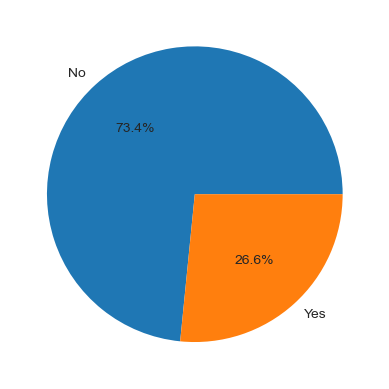

In [55]:
df_clean.Churn.value_counts(normalize=True).plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.show()

In [56]:
df_clean.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


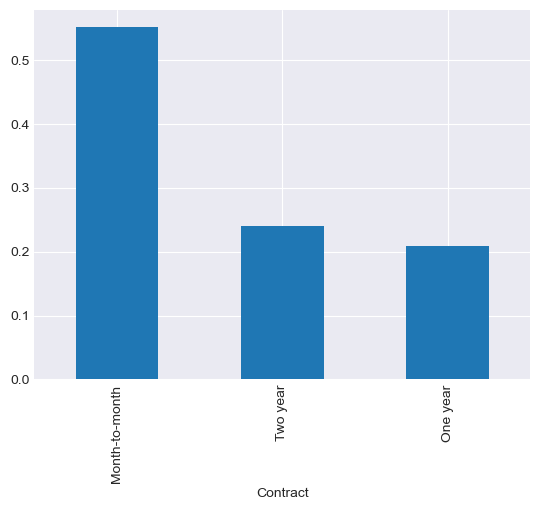

In [57]:
df_clean.Contract.value_counts(normalize=True).plot.bar()
plt.show()

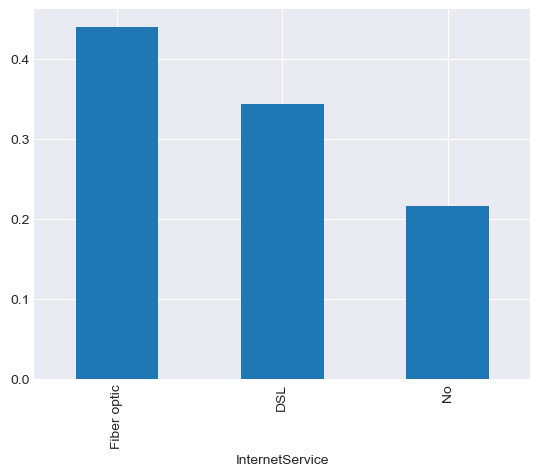

In [58]:
# 3. Churn by Internet Service
df_clean.InternetService.value_counts(normalize=True).plot.bar()
plt.show()

In [59]:
data = df_clean['InternetService'].value_counts(normalize=True)

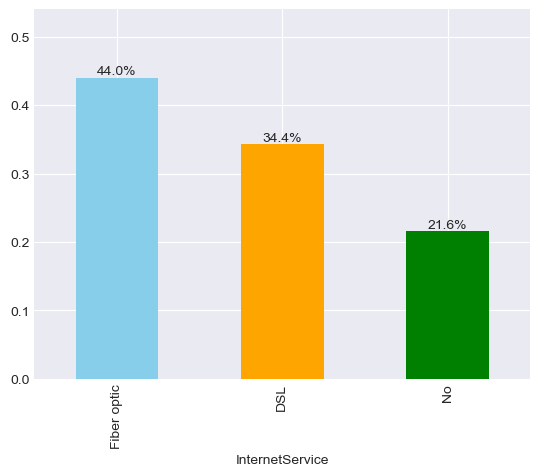

In [60]:
ax = data.plot.bar(color=['skyblue','orange','green'])

for i,v in enumerate(data):
    ax.text(i,v,f"{v*100:.1f}%",ha='center',va='bottom')

plt.ylim(0,max(data) + 0.1)
plt.show()

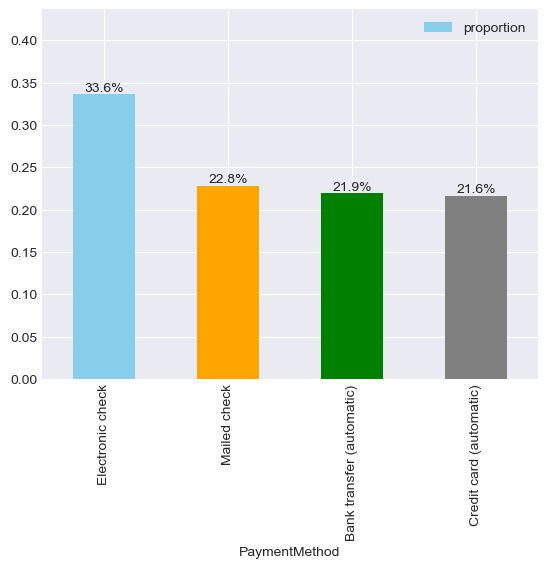

In [61]:
# 4. Churn by Payment Method
data = df_clean['PaymentMethod'].value_counts(normalize=True)

ax = data.plot.bar(color=['skyblue','orange','green','grey'])

for i,v in enumerate(data):
    ax.text(i,v,f"{v*100:.1f}%",ha='center',va='bottom')

plt.ylim(0,max(data) + 0.1)
plt.legend()
plt.show()

In [62]:
df_clean.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Feature Engineering and Encoding

In [63]:
# Identify categorical and numerical columns
cate_column = df_clean.select_dtypes(include=['object']).columns.tolist()

In [68]:
cate_column

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [66]:
cate_column.remove('customerID')

In [69]:
cate_column.remove('Churn')

In [70]:
cate_column

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [71]:
numeric_col = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()

In [72]:
numeric_col

['tenure', 'MonthlyCharges', 'TotalCharges']

In [73]:
print(cate_column)
print(numeric_col)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['tenure', 'MonthlyCharges', 'TotalCharges']


In [74]:
# Create a new feature: Tenure Groups
df_clean['tenure_group'] = pd.cut(df_clean['tenure'],
                                  bins=[0,12,24,48,60,72],
                                  labels=['0-1 year', '1-2 years', '2-4 years', '4-5 years', '5-6 years'])

In [75]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 year
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 years
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 year
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 years
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 year


In [76]:
# Create a feature: Average Monthly Charges
df_clean['avg_monthly_charge'] = df_clean['TotalCharges']/(df['tenure'] + 1) # +1 to avoid division by zero

In [77]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_charge
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 year,14.925000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 years,53.985714
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 year,36.050000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 years,40.016304
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 year,50.550000


In [78]:
# Create a feature: Customer Value Score
df_clean['customer_value'] = df_clean['MonthlyCharges'] * df_clean['tenure']

In [79]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,avg_monthly_charge,customer_value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 year,14.925000,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,2-4 years,53.985714,1936.30
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 year,36.050000,107.70
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 years,40.016304,1903.50
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 year,50.550000,141.40


In [80]:
# Encode categorical variables
le_dict = {}
for col in cate_column + ['tenure_group']:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

In [85]:
df_clean[col]

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040     No
7041    Yes
7042     No
Name: MultipleLines, Length: 7032, dtype: object

In [81]:
# Handle 'No internet service' and 'No phone service' - they mean the same as 'No' for services
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies', 'MultipleLines']

In [82]:
for col in service_cols:
    df_clean[col] = df_clean[col].replace('No internet service','No')
    df_clean[col] = df_clean[col].replace('No phone service','No')

In [86]:
# Re-encode after cleaning
for col in service_cols:
    le = LabelEncoder()
    df_clean[col + '_encoded'] = le.fit_transform(df_clean[col])
    le_dict[col] = le

In [87]:
# Encode target variable
target_encoder = LabelEncoder()
df_clean['Churn_encoded'] = target_encoder.fit_transform(df_clean['Churn'])
print(f"Churn encoding: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}")

Churn encoding: {'No': np.int64(0), 'Yes': np.int64(1)}


In [88]:
# Feature Selection and Correlation Analysis
# Select final features for modeling
feature_cols = []
feature_cols.extend([col + '_encoded' for col in cate_column if col not in service_cols])
feature_cols.extend([col + '_encoded' for col in service_cols])
feature_cols.extend(['tenure_group_encoded', 'tenure', 'MonthlyCharges', 'TotalCharges'])
feature_cols.extend(['avg_monthly_charge', 'customer_value'])

In [89]:
# Create feature matrix
X = df_clean[feature_cols]
y = df_clean['Churn_encoded']

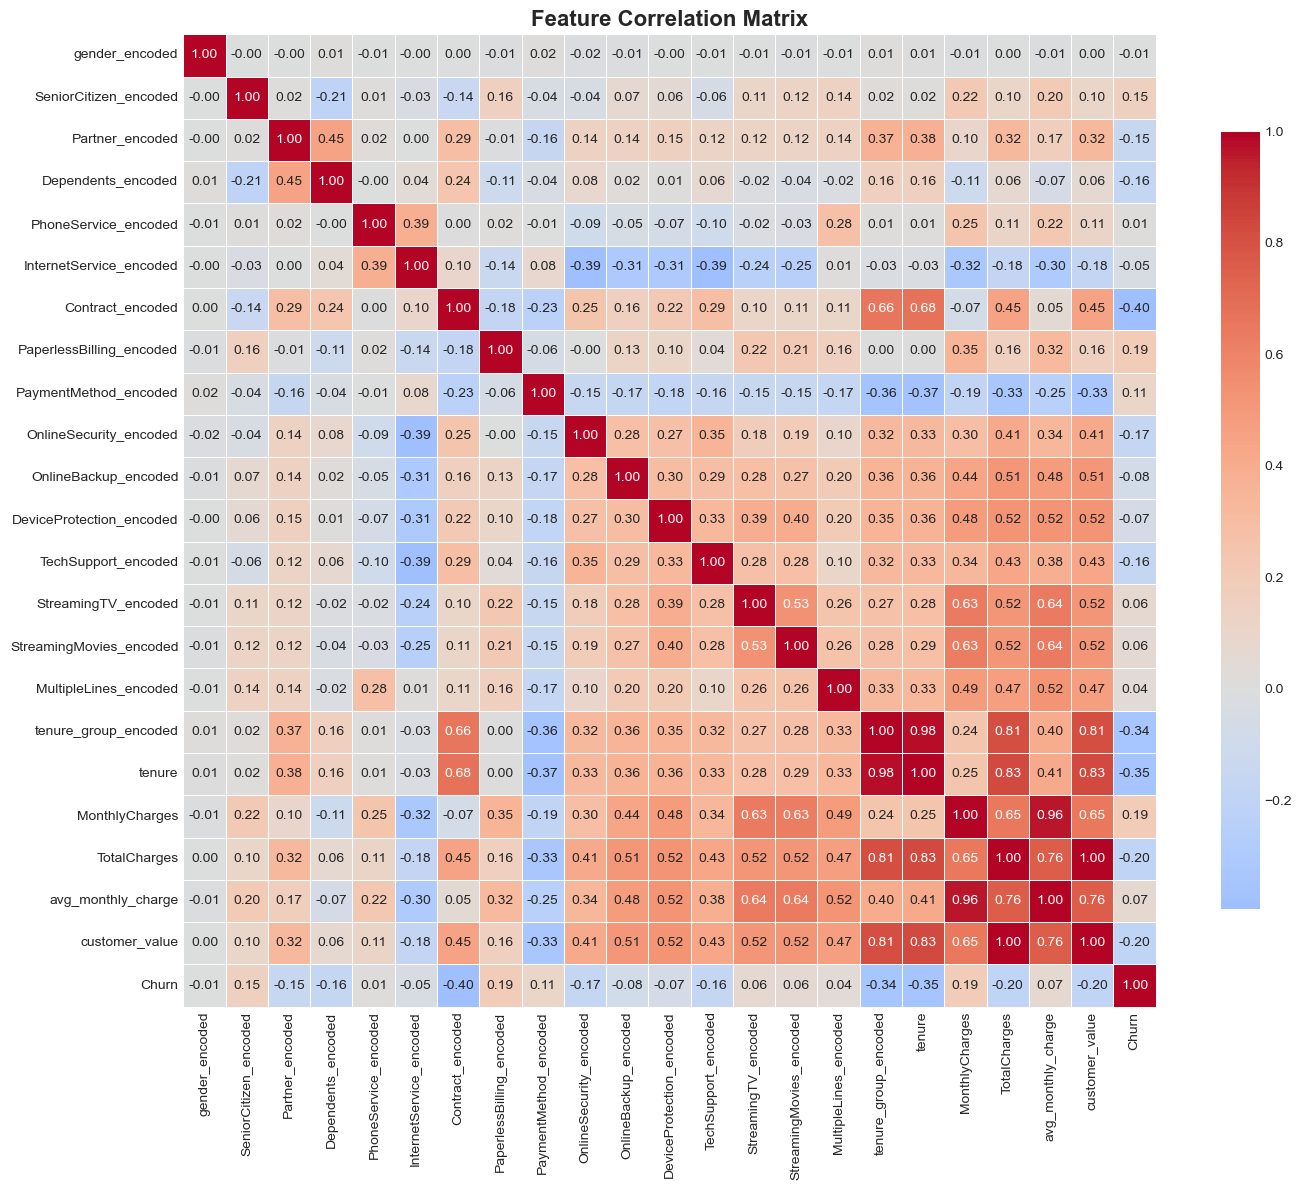

In [90]:
# Correlation matrix
plt.figure(figsize=(15, 12))
correlation_matrix = pd.concat([X,pd.Series(y,name="Churn")],axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [91]:
# Feature importance based on correlation with target
corr_with_target = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=False)
print("\nTop 10 Features correlated with Churn:")
print(corr_with_target.head(10))


Top 10 Features correlated with Churn:
MonthlyCharges              0.192858
PaperlessBilling_encoded    0.191454
SeniorCitizen_encoded       0.150541
PaymentMethod_encoded       0.107852
avg_monthly_charge          0.070992
StreamingTV_encoded         0.063254
StreamingMovies_encoded     0.060860
MultipleLines_encoded       0.040033
PhoneService_encoded        0.011691
gender_encoded             -0.008545
Name: Churn, dtype: float64


In [93]:
# Data Splitting and Scaling
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [94]:
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set churn rate: {y_train.mean():.2%}")
print(f"Test set churn rate: {y_test.mean():.2%}")


Training set size: (5625, 22)
Test set size: (1407, 22)
Training set churn rate: 26.58%
Test set churn rate: 26.58%


In [95]:
# Scale numerical features
scaler = StandardScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'customer_value']

In [96]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nScaling completed successfully!")


Scaling completed successfully!


In [97]:
# Final Prepared Dataset
# Display final dataset information
print("\n" + "="*60)
print("FINAL PREPARED DATASET SUMMARY")
print("="*60)

print(f"\nTotal features: {X_train.shape[1]}")
print(f"Features used: {feature_cols}")

print("\nFeature Statistics:")
print("="*60)
for col in feature_cols:
    print(f"{col}:")
    print(f"  - Unique values: {X_train[col].nunique()}")
    print(f"  - Data type: {X_train[col].dtype}")
    if X_train[col].dtype in ['int64', 'float64']:
        print(f"  - Range: [{X_train[col].min():.2f}, {X_train[col].max():.2f}]")

print("\n" + "="*60)
print("SAMPLE OF PREPARED TRAINING DATA")
print("="*60)
print(X_train.head())

# Save prepared data for modeling
X_train_final = X_train_scaled
X_test_final = X_test_scaled
y_train_final = y_train
y_test_final = y_test

print(f"\n✅ Data preparation complete!")
print(f"✅ Training data shape: {X_train_final.shape}")
print(f"✅ Test data shape: {X_test_final.shape}")
print(f"✅ Target variable: Churn (0 = No, 1 = Yes)")


FINAL PREPARED DATASET SUMMARY

Total features: 22
Features used: ['gender_encoded', 'SeniorCitizen_encoded', 'Partner_encoded', 'Dependents_encoded', 'PhoneService_encoded', 'InternetService_encoded', 'Contract_encoded', 'PaperlessBilling_encoded', 'PaymentMethod_encoded', 'OnlineSecurity_encoded', 'OnlineBackup_encoded', 'DeviceProtection_encoded', 'TechSupport_encoded', 'StreamingTV_encoded', 'StreamingMovies_encoded', 'MultipleLines_encoded', 'tenure_group_encoded', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_charge', 'customer_value']

Feature Statistics:
gender_encoded:
  - Unique values: 2
  - Data type: int64
  - Range: [0.00, 1.00]
SeniorCitizen_encoded:
  - Unique values: 2
  - Data type: int64
  - Range: [0.00, 1.00]
Partner_encoded:
  - Unique values: 2
  - Data type: int64
  - Range: [0.00, 1.00]
Dependents_encoded:
  - Unique values: 2
  - Data type: int64
  - Range: [0.00, 1.00]
PhoneService_encoded:
  - Unique values: 2
  - Data type: int64
  - Range: [0.0

In [98]:
X_train_scaled

,gender_encoded,SeniorCitizen_encoded,Partner_encoded,Dependents_encoded,PhoneService_encoded,InternetService_encoded,Contract_encoded,PaperlessBilling_encoded,PaymentMethod_encoded,OnlineSecurity_encoded,...,TechSupport_encoded,StreamingTV_encoded,StreamingMovies_encoded,MultipleLines_encoded,tenure_group_encoded,tenure,MonthlyCharges,TotalCharges,avg_monthly_charge,customer_value
1413,1,0,1,1,1,1,2,0,1,1,...,1,0,0,1,4,1.321816,0.981556,1.659900,1.072255,1.691052
7003,1,0,0,0,0,0,0,0,2,0,...,1,0,0,0,2,-0.267410,-0.971546,-0.562252,-0.702346,-0.603550
3355,0,0,1,0,1,1,2,0,1,0,...,1,0,0,1,4,1.444064,0.837066,1.756104,1.045031,1.685707
4494,1,0,0,0,1,1,0,0,2,0,...,0,0,1,0,0,-1.204646,0.641092,-0.908326,-0.018704,-0.901183
3541,0,0,1,0,0,0,0,0,0,1,...,0,1,0,0,3,0.669826,-0.808787,-0.101561,-0.586357,-0.136228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,1,1,1,0,1,1,1,1,0,0,...,0,0,0,0,4,1.321816,0.197658,0.990321,0.316887,1.016253
5123,0,1,0,0,1,1,0,1,1,0,...,0,0,0,0,1,-0.715654,0.342148,-0.507338,0.405154,-0.515571
4135,0,0,1,1,1,0,2,1,1,1,...,1,1,1,1,2,0.140084,0.926749,0.473507,1.047020,0.458752
4249,0,0,1,1,1,0,1,1,3,0,...,0,0,1,0,0,-0.919401,0.029917,-0.721544,0.021939,-0.722542


In [99]:
from sklearn.metrics import *

In [ ]:
# MODEL 1 : Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled,y_train_final)

y_pred_log = log_model.predict(X_test_scaled)

print("classification_report: ",classification_report(y_test_final,y_pred_log))

classification_report:                precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [102]:
# MODEL 2: Random Forest + GridSearch
# Hyperparameter Tuning

rf = RandomForestClassifier()

param_grad = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

In [103]:
grid_rf = GridSearchCV(
    rf,
    param_grad,
    cv=3,
    scoring='recall',
    n_jobs=1
)

In [104]:
grid_rf.fit(X_train_scaled,y_train_final)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall')

In [105]:
# Evaluate Random Forest
best_rf = grid_rf.best_estimator_

In [107]:
y_pred_rf = best_rf.predict(X_test_scaled)

In [108]:
print("Random Forest Results:\n")
print(classification_report(y_test_final, y_pred_rf))

Random Forest Results:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

